In [37]:
import cv2
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1. Haar Cascade
# -----------------------------
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# -----------------------------
# 2. LBP Function
# -----------------------------
def lbp_feature(img_gray):
    lbp = np.zeros_like(img_gray)
    h, w = img_gray.shape

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            center = img_gray[i, j]
            code = 0
            code |= (img_gray[i-1, j-1] > center) << 7
            code |= (img_gray[i-1, j] > center) << 6
            code |= (img_gray[i-1, j+1] > center) << 5
            code |= (img_gray[i, j+1] > center) << 4
            code |= (img_gray[i+1, j+1] > center) << 3
            code |= (img_gray[i+1, j] > center) << 2
            code |= (img_gray[i+1, j-1] > center) << 1
            code |= (img_gray[i, j-1] > center)
            lbp[i, j] = code

    # Histogram LBP - features
    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256))
    return hist


# -----------------------------
# 3. Load dataset from CASIA folder
# -----------------------------
def load_dataset(folder):
    X, y = [], []

    color_dir = os.path.join(folder, "color")
    files = os.listdir(color_dir)

    for file in files:
        if not file.endswith(".jpg"):
            continue

        label = 1 if "real" in file else 0

        img_path = os.path.join(color_dir, file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Detect face
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)
        if len(faces) == 0:
            continue

        x, y0, w, h = faces[0]
        face = gray[y0:y0 + h, x:x + w]

        face = cv2.resize(face, (128, 128))

        features = lbp_feature(face)
        X.append(features)
        y.append(label)

    return np.array(X), np.array(y)


# -----------------------------
# 4. RUN TRAIN & TEST
# -----------------------------
train_folder = "CASIA-FASD/train_img/train_img"
test_folder  = "CASIA-FASD/test_img/test_img"

print("Loading train...")
X_train, y_train = load_dataset(train_folder)

print("Loading test...")
X_test, y_test = load_dataset(test_folder)

print("Train RandomForest...")
clf = RandomForestClassifier(n_estimators=200, max_depth=30)
clf.fit(X_train, y_train)

# -----------------------------
# 5. Evaluation
# -----------------------------
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
import matplotlib.pyplot as plt

def predict_image(img_path, model):
    img = cv2.imread(img_path)
    if img is None:
        print("Cannot load image:", img_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect face
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        print("No face detected")
        return None

    x, y0, w, h = faces[0]
    face = gray[y0:y0+h, x:x+w]

    face = cv2.resize(face, (128, 128))

    feat = lbp_feature(face)

    feat = feat.reshape(1, -1)   # reshape cho sklearn
    pred = model.predict(feat)[0]
    prob = model.predict_proba(feat)[0]

    label = "REAL" if pred == 1 else "FAKE"

    # ----- Vẽ bounding box -----
    img_draw = img.copy()
    color = (0, 255, 0) if label == "REAL" else (0, 0, 255)
    cv2.rectangle(img_draw, (x, y0), (x+w, y0+h), color, 2)
    cv2.putText(img_draw, label, (x, y0 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Convert BGR → RGB để show bằng matplotlib
    img_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Prediction: {label}  |  real={prob[1]:.2f}, fake={prob[0]:.2f}")
    plt.show()

    return label, prob

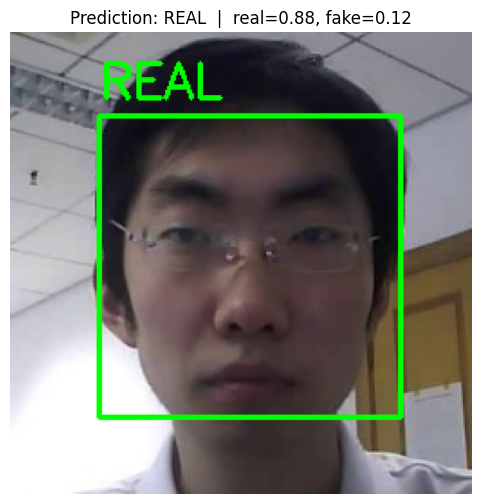

('REAL', array([0.12, 0.88]))

In [ ]:
# predict_image("/Users/mac/Documents/Software_self/VIS/VISBOX/server/lab/CASIA-FASD/train_img/train_img/color/1_1.avi_25_real.jpg", clf)

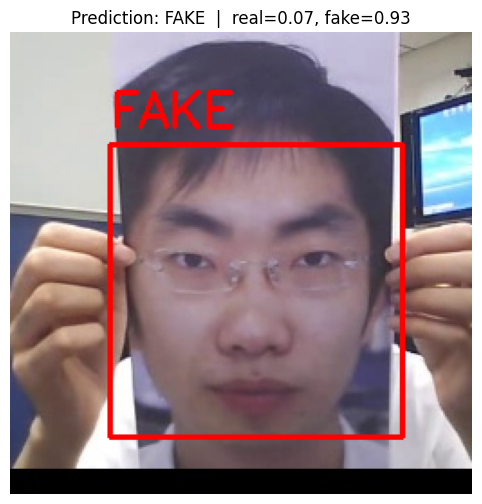

('FAKE', array([0.925, 0.075]))

In [ ]:
# predict_image("/Users/mac/Documents/Software_self/VIS/VISBOX/server/lab/CASIA-FASD/train_img/train_img/color/1_3.avi_25_fake.jpg", clf)

In [ ]:
import cv2

THRESHOLD = 0.6   # ngưỡng 85%

def run_realtime_camera(model):
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Cannot open camera")
        return

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            face = gray[y:y+h, x:x+w]
            face_resized = cv2.resize(face, (128, 128))

            feat = lbp_feature(face_resized).reshape(1, -1)

            pred = model.predict(feat)[0]
            prob = model.predict_proba(feat)[0]
            
            prob_fake = prob[0]
            prob_real = prob[1]

            # ----- ÁP DỤNG NGƯỠNG 85% -----
            if prob_real >= THRESHOLD:
                label = "REAL"
                color = (0, 255, 0)
            else:
                label = "FAKE"
                color = (0, 0, 255)

            text = f"{label} ({prob_real:.2f})"

            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
            cv2.putText(frame, text, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        cv2.imshow("Face Anti-Spoofing - Realtime", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


In [ ]:
run_realtime_camera(clf)

: 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern
from scipy import ndimage

Matplotlib is building the font cache; this may take a moment.


In [ ]:
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Không thể đọc ảnh! Kiểm tra đường dẫn.")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img, gray


In [ ]:
def extract_hog(gray):
    features, hog_image = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        block_norm='L2-Hys'
    )
    return features, hog_image


In [ ]:
def extract_lbp(gray, P=8, R=1):
    lbp = local_binary_pattern(gray, P, R, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return lbp, hist


In [ ]:
def extract_dog(gray, sigma1=1, sigma2=2):
    blur1 = cv2.GaussianBlur(gray, (0,0), sigma1)
    blur2 = cv2.GaussianBlur(gray, (0,0), sigma2)
    dog = blur1 - blur2
    return dog


In [ ]:
def extract_log(gray, sigma=1.0):
    log = ndimage.gaussian_laplace(gray, sigma)
    log = np.abs(log)
    return log


In [ ]:
def extract_canny(gray):
    edges = cv2.Canny(gray, 100, 200)
    return edges


In [ ]:
def extract_sobel(gray):
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.hypot(sobelx, sobely)
    return sobel


In [ ]:
def show(title, img):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()


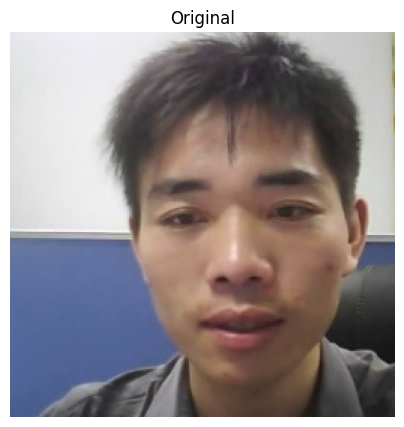

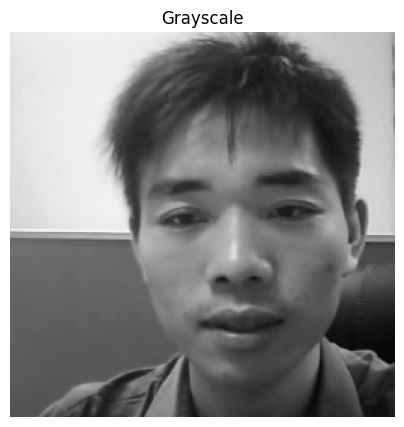

In [ ]:
img, gray = load_image("/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_1.avi_25_real.jpg")

show("Original", img)
show("Grayscale", gray)


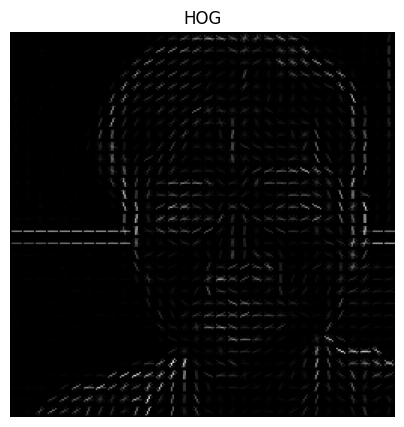

HOG feature length: 34596


In [ ]:
# HOG
hog_feat, hog_img = extract_hog(gray)
show("HOG", hog_img)
print("HOG feature length:", len(hog_feat))



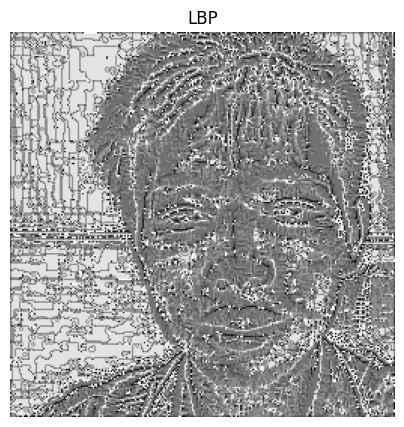

LBP histogram: [0.01219177 0.03115845 0.02052307 0.10847473 0.25146484 0.2258606
 0.06207275 0.05552673 0.18634033 0.04638672]


In [ ]:
# LBP
lbp_img, lbp_hist = extract_lbp(gray)
show("LBP", lbp_img)
print("LBP histogram:", lbp_hist)

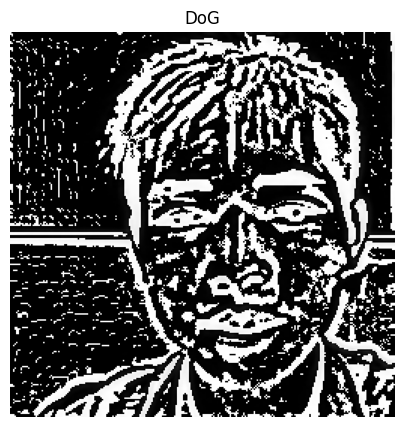

In [ ]:
# DoG
dog_img = extract_dog(gray)
show("DoG", dog_img)

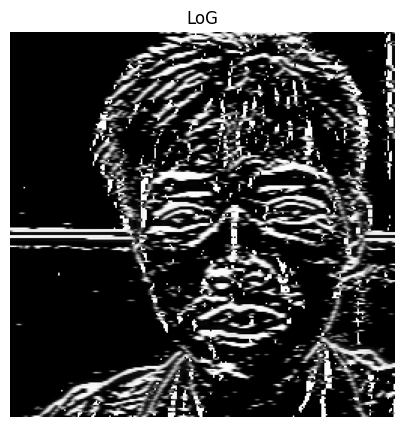

In [ ]:
# LoG
log_img = extract_log(gray)
show("LoG", log_img)


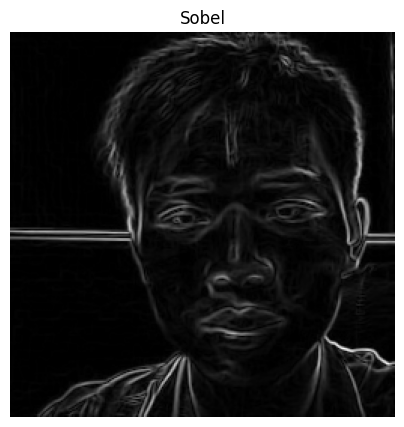

In [ ]:
# Sobel
sobel_img = extract_sobel(gray)
show("Sobel", sobel_img)

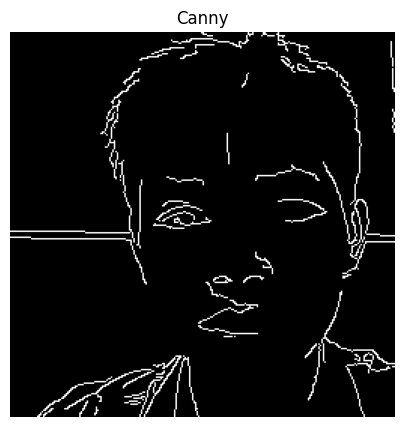

In [ ]:
# Canny
canny_img = extract_canny(gray)
show("Canny", canny_img)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

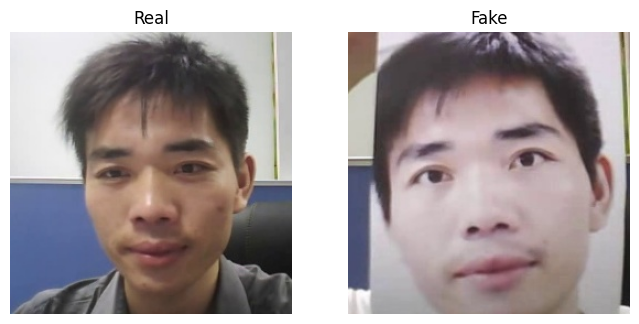

In [42]:
def load_image(path):
    return Image.open(path).convert("RGB")

img_real = load_image("/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_1.avi_100_real.jpg")
img_fake = load_image("/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_3.avi_100_fake.jpg")

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Real")
plt.imshow(img_real)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Fake")
plt.imshow(img_fake)
plt.axis("off")


In [40]:
import numpy as np
import matplotlib.pyplot as plt

def show_images(images, titles, cols=4, cmap=None):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(4*cols, 4*rows))

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)

        # 👉 FIX: convert PIL Image → numpy
        if not isinstance(img, np.ndarray):
            img = np.array(img)

        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
def center_crop(img, size=128):
    w, h = img.size
    cx, cy = w//2, h//2
    s = size//2
    return img.crop((cx-s, cy-s, cx+s, cy+s))

face_real = center_crop(img_real)
face_fake = center_crop(img_fake)

In [43]:
import numpy as np

def convolve(img, kernel):
    """
    img: 2D numpy array (grayscale)
    kernel: 2D numpy array
    """
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode="reflect")
    out = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)

    return out


In [44]:
def to_gray(img):
    return np.array(img.convert("L"), dtype=np.float32)


In [45]:
def hist_equalization(img):
    hist, bins = np.histogram(img.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf = 255 * cdf / cdf[-1]
    return cdf[img.astype(int)]

In [46]:
def laplacian(img):
    kernel = np.array([[0,1,0],
                       [1,-4,1],
                       [0,1,0]])
    return convolve(img, kernel)

In [47]:
def lbp(img):
    h, w = img.shape
    lbp_img = np.zeros_like(img)

    for i in range(1, h-1):
        for j in range(1, w-1):
            center = img[i, j]
            binary = (img[i-1:i+2, j-1:j+2] >= center).flatten()
            lbp_img[i,j] = np.sum(binary * (1 << np.arange(9)))

    return lbp_img


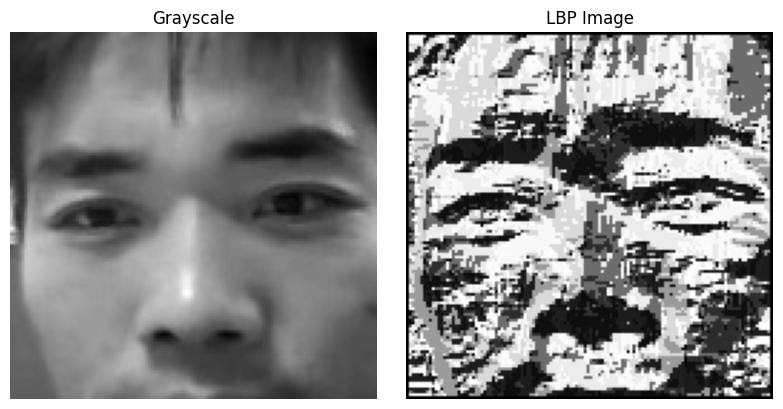

In [48]:
lbp_img = lbp(gray)

show_images(
    images=[gray, lbp_img],
    titles=["Grayscale", "LBP Image"],
    cmap="gray"
)


In [49]:
def lbp_hist(lbp_img, bins=256):
    hist, _ = np.histogram(lbp_img.flatten(), bins=bins, range=(0, bins))
    return hist / np.sum(hist)


In [50]:
def glcm_features(img):
    from skimage.feature import graycomatrix, graycoprops

    glcm = graycomatrix(img.astype(np.uint8), [1], [0], 256, symmetric=True)
    return {
        "contrast": graycoprops(glcm, "contrast")[0,0],
        "energy": graycoprops(glcm, "energy")[0,0],
        "homogeneity": graycoprops(glcm, "homogeneity")[0,0]
    }


In [51]:
def fft_energy(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    return np.mean(magnitude)


Text(0.5, 1.0, 'LBP Histogram Comparison')

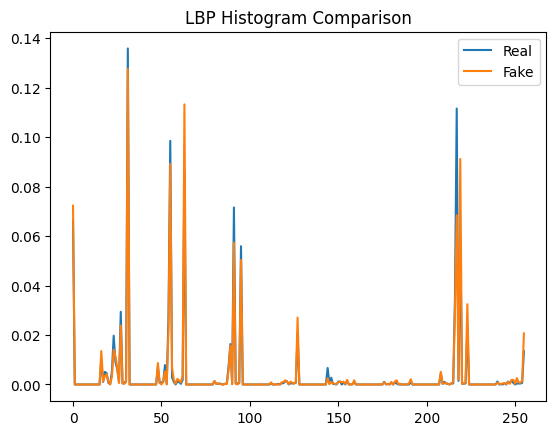

In [52]:
lbp_real = lbp_hist(lbp(to_gray(face_real)))
lbp_fake = lbp_hist(lbp(to_gray(face_fake)))

plt.plot(lbp_real, label="Real")
plt.plot(lbp_fake, label="Fake")
plt.legend()
plt.title("LBP Histogram Comparison")


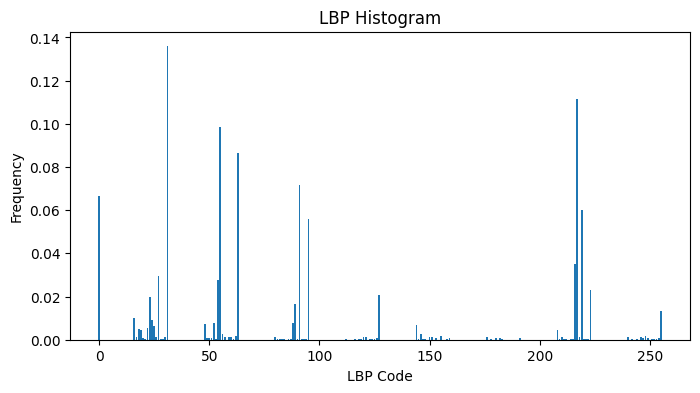

In [53]:
lbp_hist_real = lbp_hist(lbp(gray))

plt.figure(figsize=(8,4))
plt.bar(range(len(lbp_hist_real)), lbp_hist_real)
plt.title("LBP Histogram")
plt.xlabel("LBP Code")
plt.ylabel("Frequency")
plt.show()


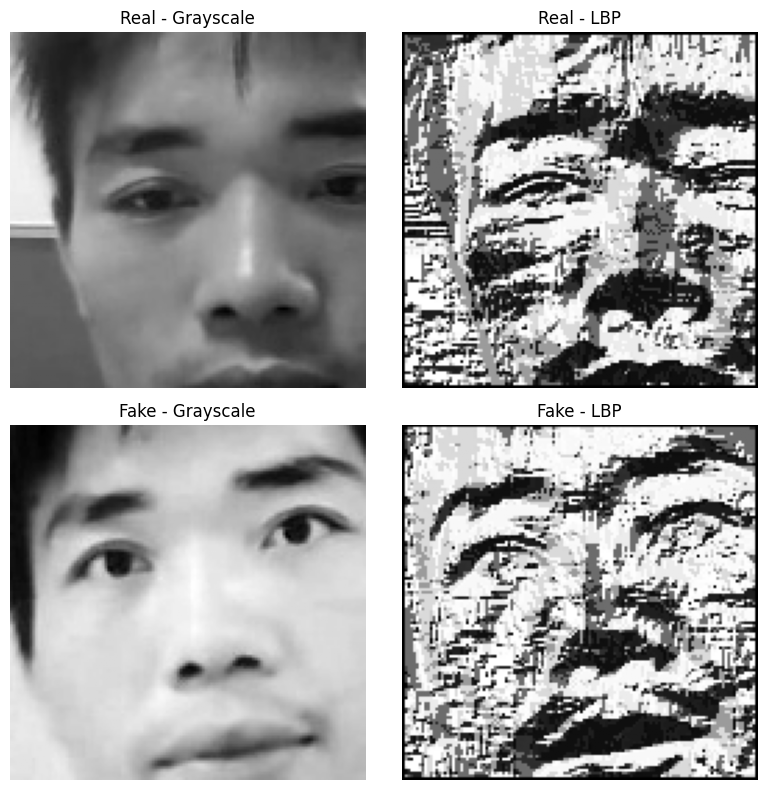

In [58]:
face_real = center_crop(load_image("/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_1.avi_25_real.jpg"))
face_fake = center_crop(load_image("/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_3.avi_25_fake.jpg"))

gray_real = to_gray(face_real)
gray_fake = to_gray(face_fake)

lbp_real = lbp(gray_real)
lbp_fake = lbp(gray_fake)

show_images(
    images=[gray_real, lbp_real, gray_fake, lbp_fake],
    titles=[
        "Real - Grayscale", "Real - LBP",
        "Fake - Grayscale", "Fake - LBP"
    ],
    cols=2,
    cmap="gray"
)


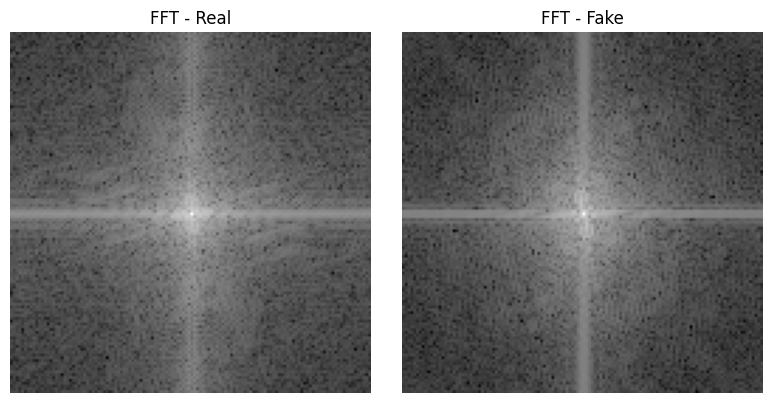

In [59]:
def fft_visual(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(1 + np.abs(fshift))
    return magnitude

fft_real = fft_visual(gray_real)
fft_fake = fft_visual(gray_fake)

show_images(
    images=[fft_real, fft_fake],
    titles=["FFT - Real", "FFT - Fake"],
    cols=2,
    cmap="gray"
)


In [60]:
def extract_features(img):
    gray = to_gray(img)
    return np.concatenate([
        lbp_hist(lbp(gray)),
        [fft_energy(gray)]
    ])


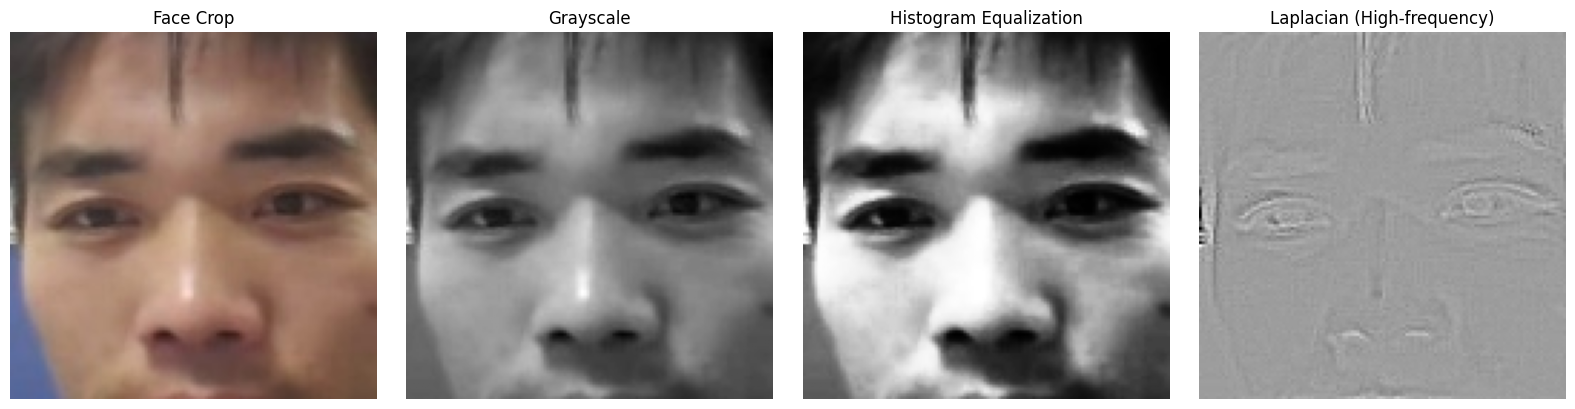

In [61]:
face = center_crop(img_real)

gray = to_gray(face)
equalized = hist_equalization(gray)
lap = laplacian(gray)

show_images(
    images=[face, gray, equalized, lap],
    titles=[
        "Face Crop",
        "Grayscale",
        "Histogram Equalization",
        "Laplacian (High-frequency)"
    ],
    cmap="gray"
)

In [62]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_1.avi_25_real.jpg").convert("RGB")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

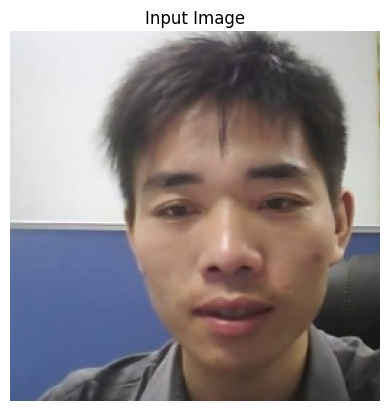

In [63]:
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

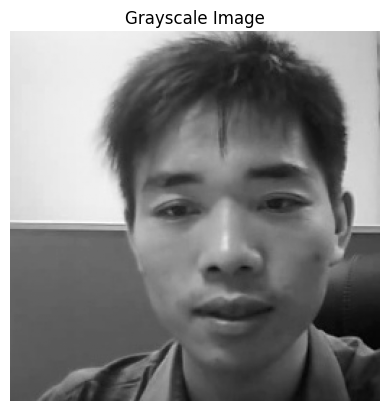

In [64]:
gray = np.array(img.convert("L"), dtype=np.float32)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

In [65]:
def integral_image(img):
    return img.cumsum(axis=0).cumsum(axis=1)

ii = integral_image(gray)


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

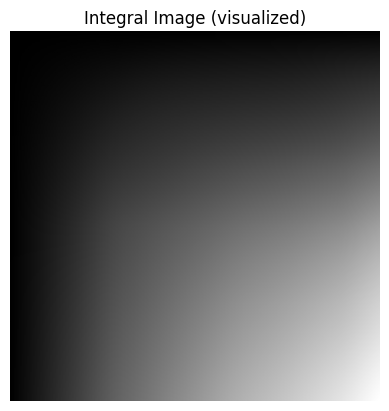

In [73]:
ii_vis = ii / ii.max() * 255

plt.imshow(ii_vis, cmap="gray")
plt.title("Integral Image (visualized)")
plt.axis("off")


In [74]:
def rect_sum(ii, x, y, w, h):
    A = ii[y-1, x-1] if x > 0 and y > 0 else 0
    B = ii[y-1, x+w-1] if y > 0 else 0
    C = ii[y+h-1, x-1] if x > 0 else 0
    D = ii[y+h-1, x+w-1]
    return D - B - C + A


In [75]:
def haar_vertical_response(ii, w=24, h=24):
    H, W = ii.shape
    response = np.zeros((H-h, W-w))

    for y in range(H-h):
        for x in range(W-w):
            left  = rect_sum(ii, x, y, w//2, h)
            right = rect_sum(ii, x+w//2, y, w//2, h)
            response[y, x] = left - right

    return response


In [76]:
haar_resp = haar_vertical_response(ii)

(np.float64(-0.5), np.float64(231.5), np.float64(231.5), np.float64(-0.5))

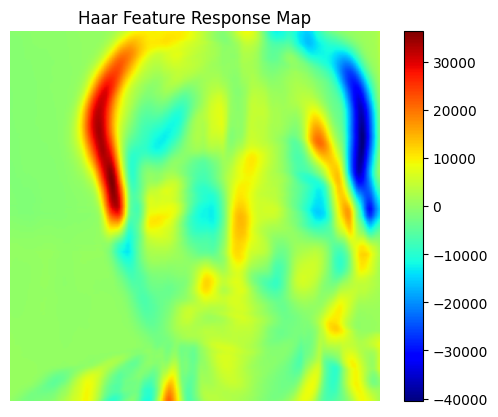

In [77]:
plt.imshow(haar_resp, cmap="jet")
plt.colorbar()
plt.title("Haar Feature Response Map")
plt.axis("off")


In [78]:
img_vis = np.array(img)

y, x = np.unravel_index(np.argmax(haar_resp), haar_resp.shape)
w = h = 24

img_vis[y:y+h, x] = [255,0,0]
img_vis[y:y+h, x+w] = [255,0,0]
img_vis[y, x:x+w] = [255,0,0]
img_vis[y+h, x:x+w] = [255,0,0]


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

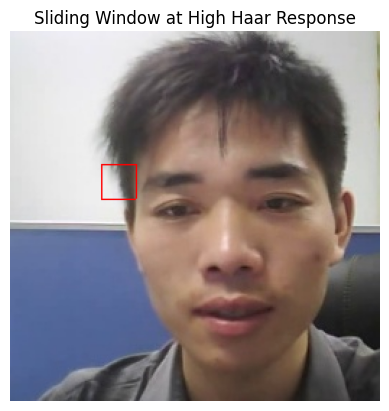

In [79]:
plt.imshow(img_vis)
plt.title("Sliding Window at High Haar Response")
plt.axis("off")


In [80]:
threshold = np.mean(haar_resp)

binary_map = haar_resp > threshold


(np.float64(-0.5), np.float64(231.5), np.float64(231.5), np.float64(-0.5))

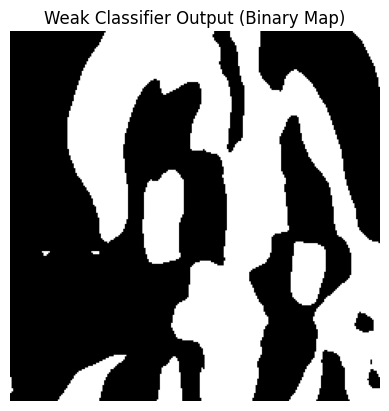

In [81]:
plt.imshow(binary_map, cmap="gray")
plt.title("Weak Classifier Output (Binary Map)")
plt.axis("off")


In [82]:
stage1 = haar_resp > np.percentile(haar_resp, 70)
stage2 = haar_resp > np.percentile(haar_resp, 85)
stage3 = haar_resp > np.percentile(haar_resp, 95)


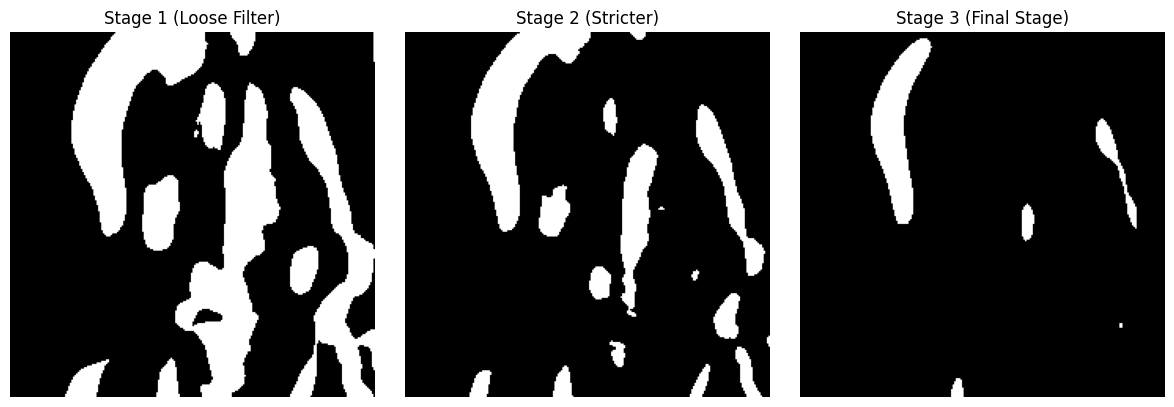

In [83]:
show_images(
    images=[stage1, stage2, stage3],
    titles=[
        "Stage 1 (Loose Filter)",
        "Stage 2 (Stricter)",
        "Stage 3 (Final Stage)"
    ],
    cols=3,
    cmap="gray"
)


In [84]:
final_map = stage3
ys, xs = np.where(final_map)

img_box = np.array(img)
for y, x in zip(ys, xs):
    img_box[y:y+24, x] = [255,0,0]
    img_box[y:y+24, x+24] = [255,0,0]
    img_box[y, x:x+24] = [255,0,0]
    img_box[y+24, x:x+24] = [255,0,0]


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

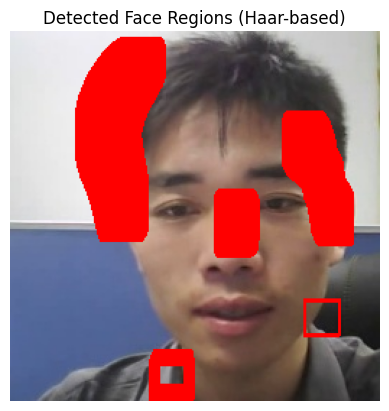

In [85]:
plt.imshow(img_box)
plt.title("Detected Face Regions (Haar-based)")
plt.axis("off")
